# Multilayer Perceptron (MLP)

---

## Introduction

Every model we have built so far — the Perceptron and Logistic Regression — is a **single neuron**. These models are powerful but fundamentally limited: they can only learn a **linear decision boundary**. If the true relationship between inputs and outputs is non-linear, a single neuron will always fall short.

The **Multilayer Perceptron (MLP)** solves this by stacking multiple layers of neurons together into a network. Each layer learns a different representation of the data, and together they can approximate remarkably complex, non-linear functions.

An MLP consists of:
- An **input layer** — one node per feature
- One or more **hidden layers** — where non-linear transformations happen
- An **output layer** — one node per output class

Training an MLP requires two phases:
1. **Feedforward** — pass input data through the network layer by layer to get a prediction
2. **Backpropagation** — compute how wrong we were, then propagate that error backwards through the network to update every weight

In this notebook we use an MLP to answer:

> *Can we predict whether a water source is safe to drink based on its chemical properties?*

**Dataset:** Water Potability — by Aditya Kadiwal  
**Source:** [Kaggle](https://www.kaggle.com/datasets/adityakadiwal/water-potability)

**Features:** pH, hardness, solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, turbidity  
**Target:** potability — `1` = safe to drink, `0` = not safe

In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom DenseNetwork from the package ─────────────────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.mlp import DenseNetwork, sigmoid, forward_pass, initialize_weights, MSE

# ── Sklearn utilities (for preprocessing and evaluation only) ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/Water_Quality.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (3276, 10)



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Step 1 — The Network Architecture

Before we build anything, let's understand exactly what an MLP looks like.

### From One Neuron to Many Layers

A single neuron computes:
$$z = w \cdot x + b \qquad \hat{y} = \sigma(z)$$

An MLP generalizes this across $L$ layers. At each layer $\ell$:

$$\mathbf{z}^{\ell} = W^{\ell} \mathbf{a}^{\ell-1} + \mathbf{b}^{\ell} \qquad \text{(pre-activation)}$$
$$\mathbf{a}^{\ell} = \sigma(\mathbf{z}^{\ell}) \qquad \text{(post-activation)}$$

Where:
- $W^{\ell}$ is the **weight matrix** for layer $\ell$ — shape $(n_\ell, n_{\ell-1})$
- $\mathbf{b}^{\ell}$ is the **bias vector** for layer $\ell$
- $\mathbf{a}^0 = \mathbf{x}^{(i)}$ — the input features
- $\sigma$ is the sigmoid activation function applied element-wise

The final output $\mathbf{a}^L$ is the network's prediction.

### Our Architecture for Water Potability

We have **9 input features** and want to predict one binary output (potable or not), so we use:

```
Input layer:    9 nodes  (one per feature)
Hidden layer 1: 64 nodes
Hidden layer 2: 32 nodes
Output layer:   1 node   (potability probability)
```

Written as `layers = [9, 64, 32, 1]`.

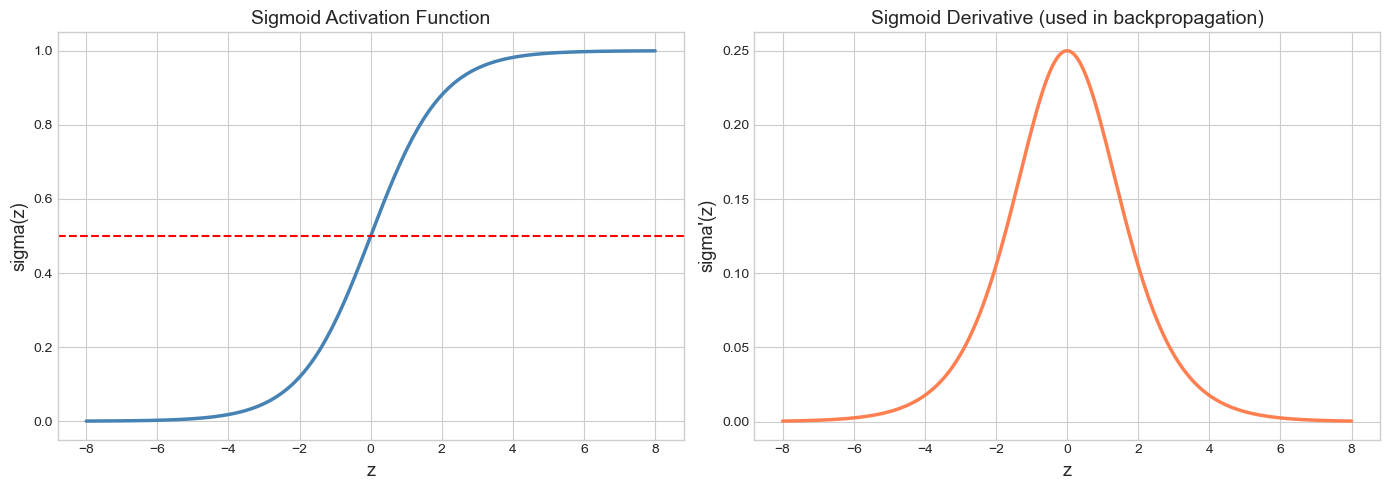

The derivative is needed in backpropagation to compute how much each
neuron contributed to the error — it tells us the slope at each point.


In [3]:
# Let's visualize the sigmoid activation function we'll use throughout the network
def d_sigmoid(z):
    return sigmoid(z) * (1 - sigmoid(z))

z = np.linspace(-8, 8, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(z, sigmoid(z), color='steelblue', linewidth=2.5)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('z', fontsize=13)
ax1.set_ylabel('sigma(z)', fontsize=13)
ax1.set_title('Sigmoid Activation Function', fontsize=14)

ax2.plot(z, d_sigmoid(z), color='coral', linewidth=2.5)
ax2.set_xlabel('z', fontsize=13)
ax2.set_ylabel("sigma'(z)", fontsize=13)
ax2.set_title('Sigmoid Derivative (used in backpropagation)', fontsize=14)

plt.tight_layout()
plt.show()

print('The derivative is needed in backpropagation to compute how much each')
print('neuron contributed to the error — it tells us the slope at each point.')

In [4]:
# Let's manually inspect what weight initialization looks like
# for our [9, 64, 32, 1] network

layers = [9, 64, 32, 1]
W, B = initialize_weights(layers)

print('Weight matrix shapes for each layer:')
for i in range(1, len(layers)):
    print(f'  Layer {i}: W[{i}] shape = {W[i].shape}  '
          f'(connects {layers[i-1]} nodes → {layers[i]} nodes)')
print()
print('Bias vector shapes for each layer:')
for i in range(1, len(layers)):
    print(f'  Layer {i}: B[{i}] shape = {B[i].shape}')

Weight matrix shapes for each layer:
  Layer 1: W[1] shape = (64, 9)  (connects 9 nodes → 64 nodes)
  Layer 2: W[2] shape = (32, 64)  (connects 64 nodes → 32 nodes)
  Layer 3: W[3] shape = (1, 32)  (connects 32 nodes → 1 nodes)

Bias vector shapes for each layer:
  Layer 1: B[1] shape = (64, 1)
  Layer 2: B[2] shape = (32, 1)
  Layer 3: B[3] shape = (1, 1)


## Step 2 — Understanding the Data

We have **3,276 water samples** tested for 9 chemical properties. Each sample is labeled as potable (safe) or not.

### Why this dataset?

Access to clean drinking water is a global health crisis — contaminated water causes millions of deaths each year. Automating the detection of unsafe water from chemical measurements could help health officials flag dangerous water sources faster and more consistently than manual testing alone.

### Why MLP and not Logistic Regression?

The relationship between chemical properties and water safety is almost certainly **non-linear**. For example, both very low and very high pH can be dangerous — a single neuron can't capture a U-shaped relationship. An MLP with hidden layers can.

In [5]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


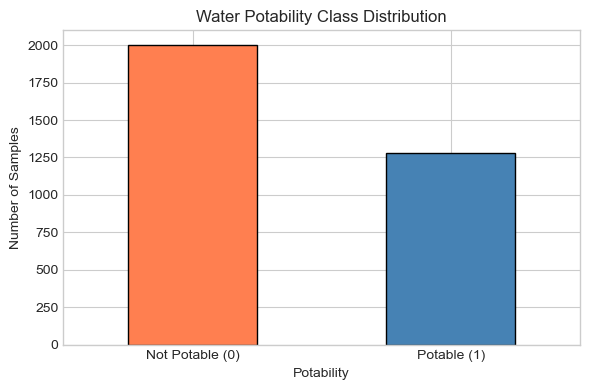

Not potable (0): 1998
Potable     (1): 1278


In [7]:
# Plot the class distribution — is the dataset balanced?
plt.figure(figsize=(6, 4))
df['Potability'].value_counts().plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['Not Potable (0)', 'Potable (1)'], rotation=0)
plt.ylabel('Number of Samples')
plt.title('Water Potability Class Distribution')
plt.tight_layout()
plt.show()

print(f'Not potable (0): {(df["Potability"] == 0).sum()}')
print(f'Potable     (1): {(df["Potability"] == 1).sum()}')

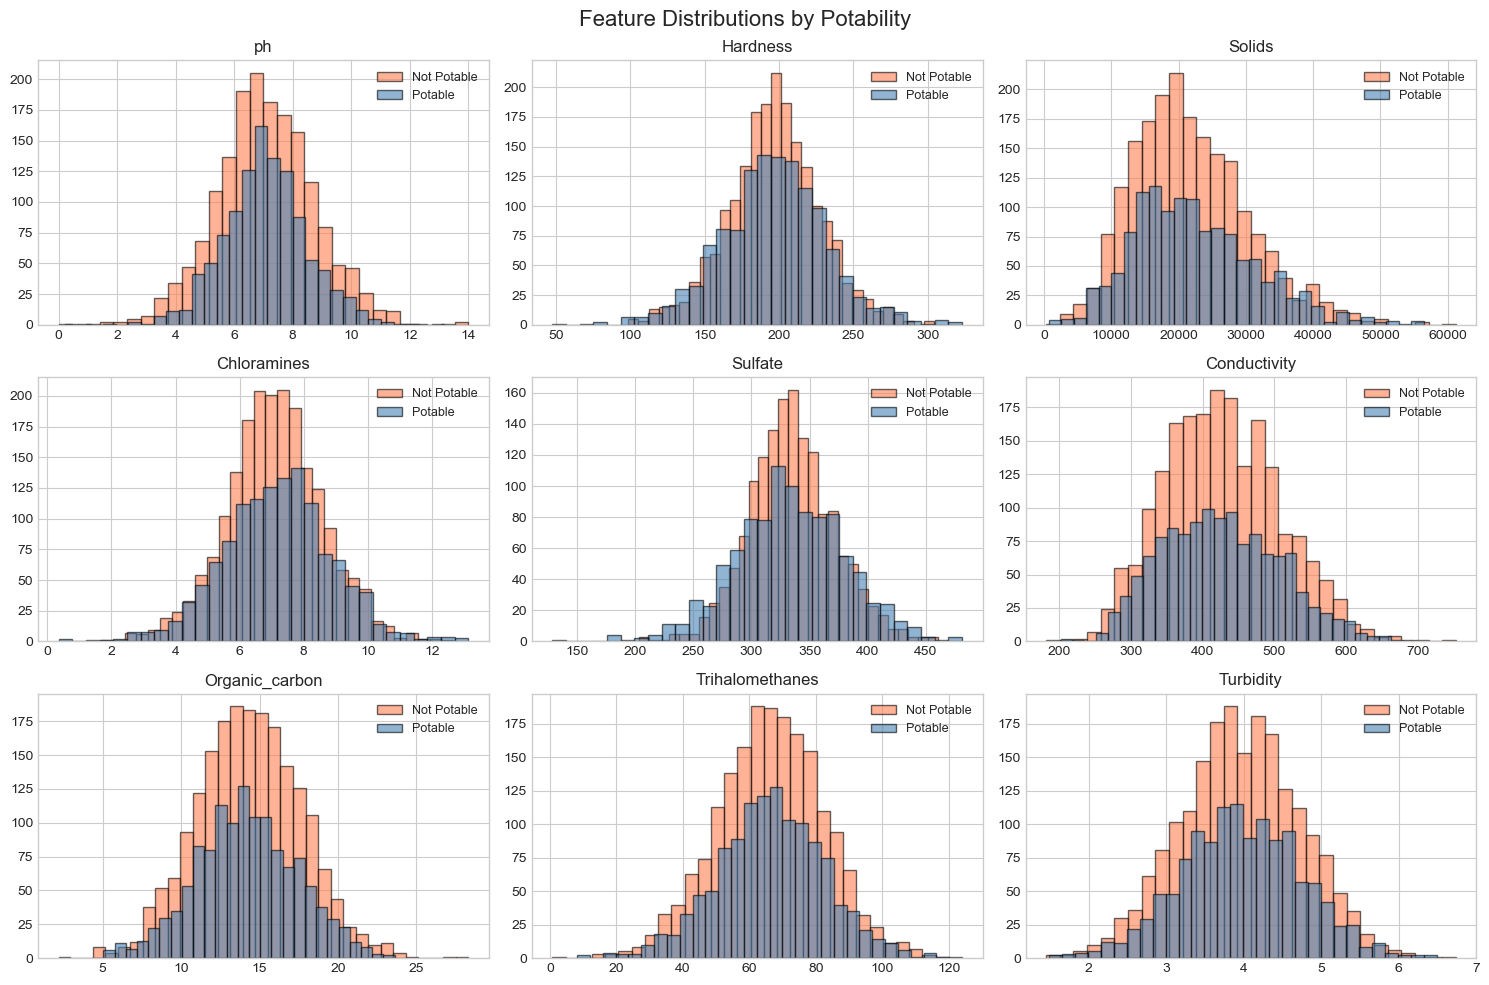

In [8]:
# Visualize the distribution of each feature, colored by potability
feature_cols = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions by Potability', fontsize=16)

for ax, col in zip(axs.flat, feature_cols):
    ax.hist(df[df['Potability'] == 0][col].dropna(), bins=30,
            alpha=0.6, color='coral', edgecolor='black', label='Not Potable')
    ax.hist(df[df['Potability'] == 1][col].dropna(), bins=30,
            alpha=0.6, color='steelblue', edgecolor='black', label='Potable')
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 3 — Feedforward and Backpropagation

Before training the full network, let's walk through the two key phases manually.

### Feedforward

Data flows **forward** through the network, layer by layer:

$$\mathbf{a}^0 = \mathbf{x}^{(i)} \xrightarrow{W^1, b^1} \mathbf{z}^1, \mathbf{a}^1 \xrightarrow{W^2, b^2} \mathbf{z}^2, \mathbf{a}^2 \xrightarrow{W^3, b^3} \mathbf{z}^3, \mathbf{a}^3 = \hat{y}$$

### Backpropagation

After feedforward, we compute how wrong we were and propagate that error **backwards**. The key quantity is the **delta** $\delta^\ell$ — how much layer $\ell$ contributed to the total error.

**Output layer error:**
$$\delta^L = (\mathbf{a}^L - \mathbf{y}^{(i)}) \odot \sigma'(\mathbf{z}^L)$$

**Hidden layer errors (propagated backwards):**
$$\delta^\ell = \big((W^{\ell+1})^T \delta^{\ell+1}\big) \odot \sigma'(\mathbf{z}^\ell)$$

**Weight and bias updates:**
$$W^\ell \leftarrow W^\ell - \alpha \cdot \delta^\ell (\mathbf{a}^{\ell-1})^T$$
$$\mathbf{b}^\ell \leftarrow \mathbf{b}^\ell - \alpha \cdot \delta^\ell$$

Where $\odot$ denotes element-wise multiplication.

In [9]:
# Let's manually run one feedforward pass to see the shapes at each layer
# We'll use a fake input vector with 9 features (one per water quality measure)

W, B = initialize_weights([9, 64, 32, 1])

# Create a fake input — 9 features reshaped into a column vector (9, 1)
fake_input = np.random.randn(9, 1)
fake_label = np.array([[1.0]])   # this sample is potable

Z, A = forward_pass(W, B, fake_input)

print('Feedforward pass — shapes at each layer:')
print(f'  a^0 (input):          {A[0].shape}')
print(f'  a^1 (hidden layer 1): {A[1].shape}')
print(f'  a^2 (hidden layer 2): {A[2].shape}')
print(f'  a^3 (output):         {A[3].shape}')
print()
print(f'Raw network output (before training): {A[-1][0][0]:.4f}')
print(f'This is the predicted probability of the water being potable.')

Feedforward pass — shapes at each layer:
  a^0 (input):          (9, 1)
  a^1 (hidden layer 1): (64, 1)
  a^2 (hidden layer 2): (32, 1)
  a^3 (output):         (1, 1)

Raw network output (before training): 0.6729
This is the predicted probability of the water being potable.


## Step 4 — Preprocessing

Before training we need to:
1. **Handle missing values** — fill NaN with column means
2. **Scale features** — neural networks are very sensitive to scale
3. **Split into train/test sets**
4. **Reformat data** — our network expects column vectors, not rows

In [10]:
# Step 1: Fill missing values with column mean
# (dropping rows would lose too much data — we have missing values in 3 columns)
df_clean = df.copy()
for col in feature_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

print('Missing values after filling:')
print(df_clean[feature_cols].isnull().sum())

Missing values after filling:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


In [11]:
# Step 2 & 3: Scale features and split into train/test
X = df_clean[feature_cols].to_numpy()
y = df_clean['Potability'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit scaler on training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')

Training set: 2620 samples
Test set:     656 samples


In [12]:
# Step 4: Reformat data into column vectors
# Our DenseNetwork expects each input xi to be a column vector of shape (num_features, 1)
# and each label yi to be a column vector of shape (1, 1)

X_train_vecs = [x.reshape(-1, 1) for x in X_train]
X_test_vecs  = [x.reshape(-1, 1) for x in X_test]
y_train_vecs = [np.array([[float(yi)]]) for yi in y_train]
y_test_labels = list(y_test)   # keep flat list for accuracy calculation

print('Input shape per sample:  ', X_train_vecs[0].shape)
print('Label shape per sample:  ', y_train_vecs[0].shape)

Input shape per sample:   (9, 1)
Label shape per sample:   (1, 1)


## Step 5 — Training and Evaluation

Now we initialize and train our `DenseNetwork`. We'll:
- Start with MSE before training to show the baseline
- Train for several epochs and watch the loss fall
- Evaluate with accuracy, confusion matrix, and classification report
- Compare performance against our simpler models

In [13]:
# Initialize the network with architecture [9, 64, 32, 1]
# 9 inputs (water features) → 64 hidden → 32 hidden → 1 output (potability)
np.random.seed(42)
net = DenseNetwork(layers=[9, 64, 32, 1])

# Check MSE before any training
print(f'MSE before training: {MSE(net.W, net.B, X_train_vecs, y_train_vecs):.4f}')
print()
print('Starting training...')
net.train(X_train_vecs, y_train_vecs, alpha=0.01, epochs=10)

MSE before training: 0.2173

Starting training...
Starting MSE = 0.2173
Epoch 1 MSE = 0.1206
Epoch 2 MSE = 0.1205
Epoch 3 MSE = 0.1204
Epoch 4 MSE = 0.1203
Epoch 5 MSE = 0.1203
Epoch 6 MSE = 0.1202
Epoch 7 MSE = 0.1202
Epoch 8 MSE = 0.1201
Epoch 9 MSE = 0.1201
Epoch 10 MSE = 0.1200


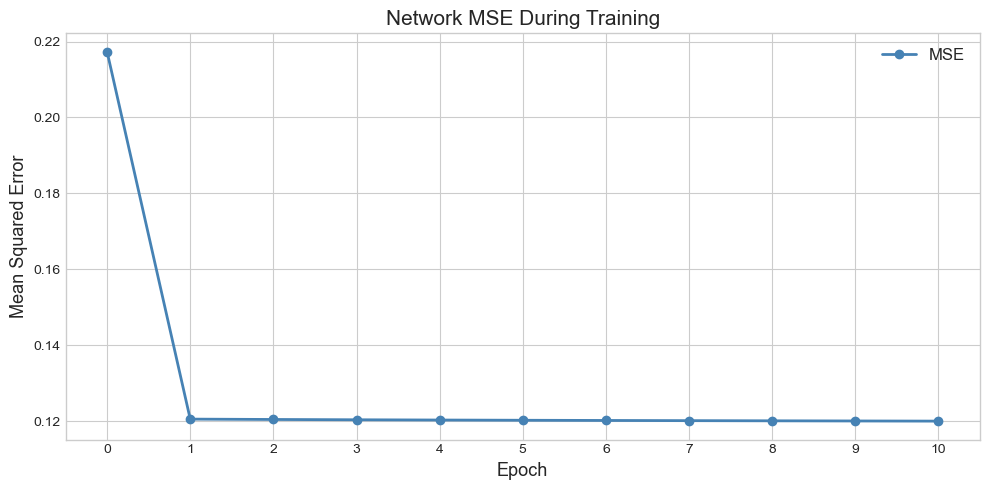

In [14]:
# Plot the training loss curve
plt.figure(figsize=(10, 5))
epochs_range = range(len(net.loss_history))
plt.plot(epochs_range, net.loss_history, marker='o', color='steelblue', linewidth=2, label='MSE')
plt.xticks(epochs_range)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Mean Squared Error', fontsize=13)
plt.title('Network MSE During Training', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# Evaluate on the test set
train_acc = net.accuracy(X_train_vecs, list(y_train))
test_acc  = net.accuracy(X_test_vecs, y_test_labels)

print(f'Training Accuracy: {train_acc*100:.2f}%')
print(f'Test Accuracy:     {test_acc*100:.2f}%')

Training Accuracy: 60.38%
Test Accuracy:     62.50%


In [16]:
# Full classification report
y_pred = [net.predict(xi) for xi in X_test_vecs]

print('Classification Report:')
print(classification_report(y_test_labels, y_pred,
                            target_names=['Not Potable (0)', 'Potable (1)']))

Classification Report:
                 precision    recall  f1-score   support

Not Potable (0)       0.63      1.00      0.77       412
    Potable (1)       0.00      0.00      0.00       244

       accuracy                           0.62       656
      macro avg       0.31      0.50      0.38       656
   weighted avg       0.39      0.62      0.48       656



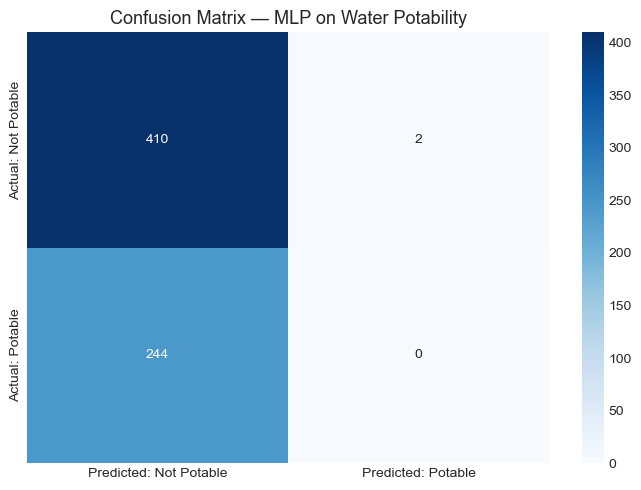

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Not Potable', 'Predicted: Potable'],
            yticklabels=['Actual: Not Potable', 'Actual: Potable'])
plt.title('Confusion Matrix — MLP on Water Potability', fontsize=13)
plt.tight_layout()
plt.show()

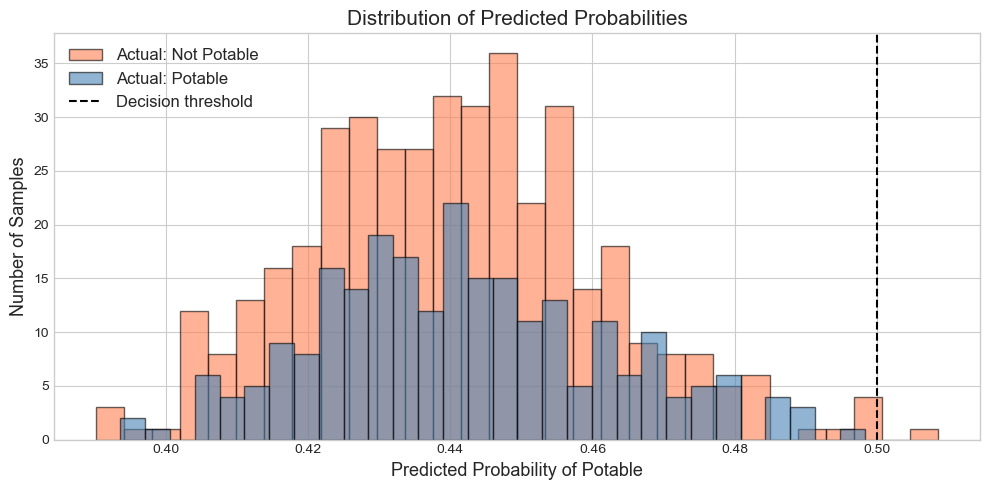

In [18]:
# Distribution of predicted probabilities
probas = [net.predict_proba(xi) for xi in X_test_vecs]

plt.figure(figsize=(10, 5))
plt.hist([p for p, y in zip(probas, y_test_labels) if y == 0],
         bins=30, alpha=0.6, color='coral', edgecolor='black', label='Actual: Not Potable')
plt.hist([p for p, y in zip(probas, y_test_labels) if y == 1],
         bins=30, alpha=0.6, color='steelblue', edgecolor='black', label='Actual: Potable')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold')
plt.xlabel('Predicted Probability of Potable', fontsize=13)
plt.ylabel('Number of Samples', fontsize=13)
plt.title('Distribution of Predicted Probabilities', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Step 6 — Conclusion

### What did we find?

Our MLP was trained to predict whether a water source is safe to drink based on 9 chemical measurements, using a `[9, 64, 32, 1]` network architecture trained with Stochastic Gradient Descent and Backpropagation.

### Why MLP over Logistic Regression?

The chemical relationship between properties like pH, sulfate, and trihalomethanes and water safety is fundamentally non-linear — both extremes of pH are dangerous, not just one end. A single neuron can only draw a straight line and would systematically miss these patterns. The hidden layers of an MLP allow the network to learn curved, complex decision boundaries that better capture the true structure of the data.

### Backpropagation — The Key Insight

The reason MLPs can be trained at all is **backpropagation**. By applying the chain rule layer by layer from the output back to the input, we can compute exactly how much each weight in the network contributed to the final error — and adjust each one accordingly. Without backpropagation, training a multi-layer network would be computationally intractable.

### Limitations

1. **Slow training** — our implementation uses pure Python loops for SGD. Real deep learning frameworks (TensorFlow, PyTorch) use vectorized batch operations and GPUs that are orders of magnitude faster.
2. **Hyperparameter sensitivity** — learning rate, number of layers, and number of nodes per layer all affect performance significantly and require tuning.
3. **Imbalanced classes** — the dataset has more non-potable than potable samples, which can bias the model toward predicting the majority class.
4. **Sigmoid vanishing gradient** — for very deep networks, sigmoid derivatives become very small in early layers, making learning slow. Modern networks use ReLU instead.

### What's next?

In the following notebooks we move to **K-Nearest Neighbors** and **Decision Trees** — algorithms that take a completely different approach and don't use gradient descent at all!